Dataset:
        class handicapped_infants water_project_cost_sharing  \
0  republican                   n                          y   
1  republican                   n                          y   
2    democrat                 NaN                          y   
3    democrat                   n                          y   
4    democrat                   y                          y   

  adoption_of_budget_resolution physician_fee_freeze el_salvador_aid  \
0                             n                    y               y   
1                             n                    y               y   
2                             y                  NaN               y   
3                             y                    n             NaN   
4                             y                    n               y   

  religious_groups_in_schools anti_satellite_test_ban  \
0                           y                       n   
1                           y                       n   
2 

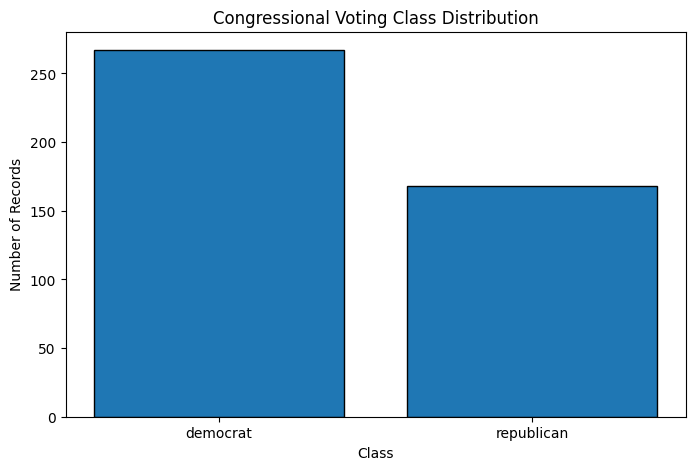

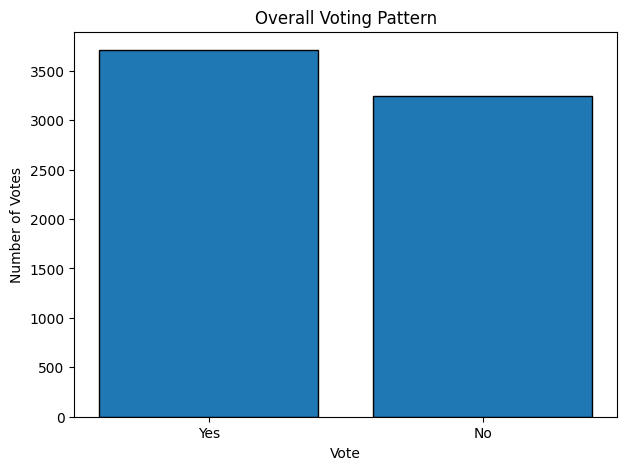

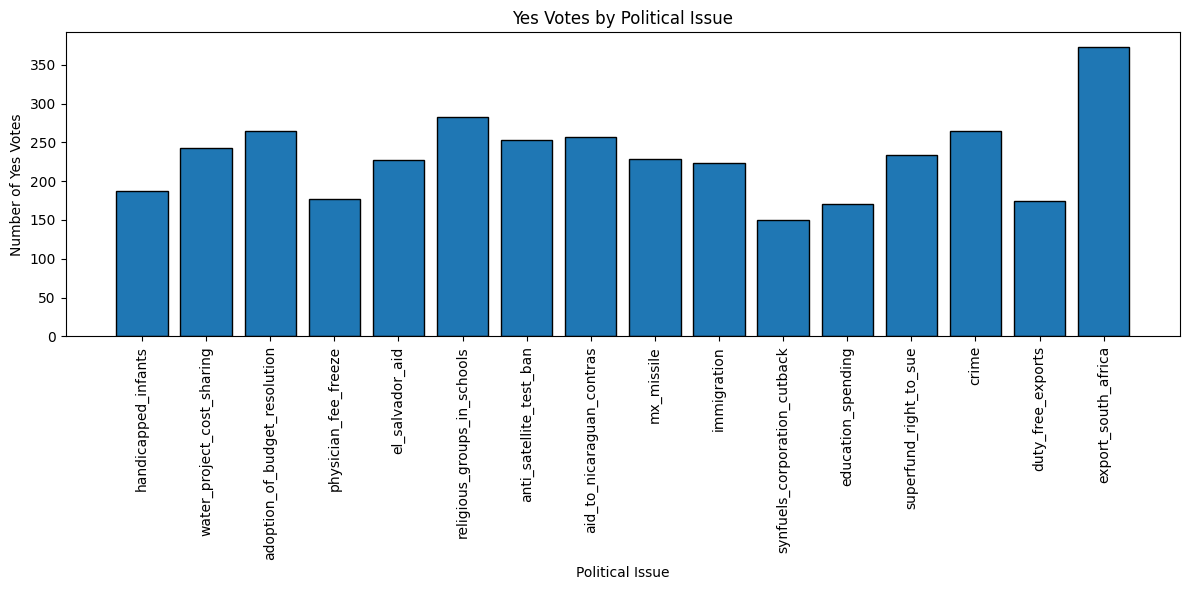

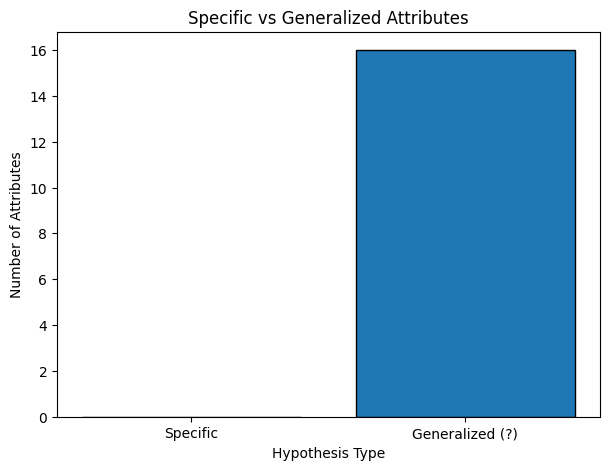


Cleaned dataset saved successfully.

Candidate Elimination completed successfully.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Load Congressional Voting Records Dataset
# ---------------------------------------------------

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/voting-records/house-votes-84.data"

columns = [
    "class",
    "handicapped_infants",
    "water_project_cost_sharing",
    "adoption_of_budget_resolution",
    "physician_fee_freeze",
    "el_salvador_aid",
    "religious_groups_in_schools",
    "anti_satellite_test_ban",
    "aid_to_nicaraguan_contras",
    "mx_missile",
    "immigration",
    "synfuels_corporation_cutback",
    "education_spending",
    "superfund_right_to_sue",
    "crime",
    "duty_free_exports",
    "export_south_africa"
]

df = pd.read_csv(
    url,
    header=None,
    names=columns,
    na_values="?"
)

print("Dataset:")
print(df.head())


# ---------------------------------------------------
# Dataset Information
# ---------------------------------------------------

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["class"].value_counts())


# ---------------------------------------------------
# Handle Missing Values
# ---------------------------------------------------

for column in columns:
    if df[column].isnull().any():
        df[column] = df[column].fillna(
            df[column].mode()[0]
        )

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


# ---------------------------------------------------
# Prepare X and y
# ---------------------------------------------------

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

attributes = list(df.columns[1:])


# ---------------------------------------------------
# Initial Specific and General Hypotheses
# ---------------------------------------------------

S = ["∅"] * len(attributes)

G = [["?"] * len(attributes)]


# ---------------------------------------------------
# Covers Function
# ---------------------------------------------------

def covers(h, x):

    for i in range(len(h)):

        if h[i] != "?" and h[i] != "∅":

            if h[i] != x[i]:
                return False

    return True


# ---------------------------------------------------
# Candidate Elimination Algorithm
# ---------------------------------------------------

for x, label in zip(X, y):

    # Positive Example
    if label == "democrat":

        # Remove general hypotheses
        # that do not cover positive example
        G = [
            g for g in G
            if covers(g, x)
        ]

        # First positive example
        if S == ["∅"] * len(attributes):

            S = list(x)

        else:

            # Generalize S
            for i in range(len(attributes)):

                if S[i] != x[i]:

                    S[i] = "?"


    # Negative Example
    elif label == "republican":

        new_G = []

        for g in G:

            # If G hypothesis covers negative example
            if covers(g, x):

                for i in range(len(attributes)):

                    if g[i] == "?":

                        if (
                            S[i] != "?"
                            and S[i] != "∅"
                        ):

                            h = g.copy()

                            h[i] = S[i]

                            if h not in new_G:

                                new_G.append(h)

            else:

                new_G.append(g)

        G = new_G


# ---------------------------------------------------
# Results
# ---------------------------------------------------

print("\nNumber of Positive Examples:")
print(sum(y == "democrat"))

print("\nNumber of Negative Examples:")
print(sum(y == "republican"))


print("\nMost Specific Hypothesis:")
print(S)


print("\nMost General Hypotheses:")

if len(G) == 0:

    print("Empty")

else:

    for g in G:
        print(g)


# ---------------------------------------------------
# Version Space
# ---------------------------------------------------

print("\nFinal Version Space:")

print("\nSpecific Boundary (S):")
print(S)

print("\nGeneral Boundary (G):")

if len(G) == 0:

    print("Empty")

else:

    for g in G:
        print(g)


# ---------------------------------------------------
# Graph 1: Class Distribution
# ---------------------------------------------------

class_counts = df["class"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    class_counts.index,
    class_counts.values,
    edgecolor="black"
)

plt.title("Congressional Voting Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Records")

plt.show()


# ---------------------------------------------------
# Graph 2: Yes vs No Votes
# ---------------------------------------------------

vote_columns = attributes

yes_count = 0
no_count = 0

for column in vote_columns:

    yes_count += (df[column] == "y").sum()
    no_count += (df[column] == "n").sum()

vote_data = {
    "Yes": yes_count,
    "No": no_count
}

plt.figure(figsize=(7, 5))

plt.bar(
    vote_data.keys(),
    vote_data.values(),
    edgecolor="black"
)

plt.title("Overall Voting Pattern")
plt.xlabel("Vote")
plt.ylabel("Number of Votes")

plt.show()


# ---------------------------------------------------
# Graph 3: Votes by Issue
# ---------------------------------------------------

issue_yes_votes = []

for column in vote_columns:

    issue_yes_votes.append(
        (df[column] == "y").sum()
    )


plt.figure(figsize=(12, 6))

plt.bar(
    vote_columns,
    issue_yes_votes,
    edgecolor="black"
)

plt.title("Yes Votes by Political Issue")
plt.xlabel("Political Issue")
plt.ylabel("Number of Yes Votes")

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.show()


# ---------------------------------------------------
# Graph 4: Hypothesis Boundary
# ---------------------------------------------------

specific_attributes = sum(
    1 for value in S
    if value != "?"
)

generalized_attributes = sum(
    1 for value in S
    if value == "?"
)

hypothesis_data = {
    "Specific": specific_attributes,
    "Generalized (?)": generalized_attributes
}

plt.figure(figsize=(7, 5))

plt.bar(
    hypothesis_data.keys(),
    hypothesis_data.values(),
    edgecolor="black"
)

plt.title("Specific vs Generalized Attributes")
plt.xlabel("Hypothesis Type")
plt.ylabel("Number of Attributes")

plt.show()


# ---------------------------------------------------
# Save Cleaned Dataset
# ---------------------------------------------------

df.to_csv(
    "Congressional_Voting_Cleaned.csv",
    index=False
)

print("\nCleaned dataset saved successfully.")

print("\nCandidate Elimination completed successfully.")

In [ ]:
import pandas as pd

# ---------------------------------------------------
# Load Zoo Dataset
# ---------------------------------------------------

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/zoo/zoo.data"

columns = [
    "animal_name",
    "hair",
    "feathers",
    "eggs",
    "milk",
    "airborne",
    "aquatic",
    "predator",
    "toothed",
    "backbone",
    "breathes",
    "venomous",
    "fins",
    "legs",
    "tail",
    "domestic",
    "catsize",
    "class_type"
]

df = pd.read_csv(
    url,
    header=None,
    names=columns
)

print("Dataset:")
print(df.head())


# ---------------------------------------------------
# Dataset Information
# ---------------------------------------------------

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["class_type"].value_counts())


# ---------------------------------------------------
# Prepare X and y
# ---------------------------------------------------

# Use animal characteristics as attributes
X = df.iloc[:, 1:-1].values

# Use class 1 (Mammal) as the positive class
y = df["class_type"].values

attributes = list(df.columns[1:-1])


# ---------------------------------------------------
# Initial Specific and General Hypotheses
# ---------------------------------------------------

S = ["∅"] * len(attributes)

G = [["?"] * len(attributes)]


# ---------------------------------------------------
# Covers Function
# ---------------------------------------------------

def covers(h, x):

    for i in range(len(h)):

        if h[i] != "?" and h[i] != "∅":

            if h[i] != x[i]:

                return False

    return True


# ---------------------------------------------------
# Candidate Elimination Algorithm
# ---------------------------------------------------

for x, label in zip(X, y):

    # Positive example: Mammal
    if label == 1:

        # Remove general hypotheses
        # that do not cover the positive example
        G = [
            g for g in G
            if covers(g, x)
        ]

        # First positive example
        if S == ["∅"] * len(attributes):

            S = list(x)

        else:

            # Generalize S
            for i in range(len(attributes)):

                if S[i] != x[i]:

                    S[i] = "?"


    # Negative example: Non-mammal
    else:

        new_G = []

        for g in G:

            # If G covers negative example
            if covers(g, x):

                for i in range(len(attributes)):

                    if g[i] == "?":

                        if (
                            S[i] != "?"
                            and S[i] != "∅"
                        ):

                            h = g.copy()

                            h[i] = S[i]

                            if h not in new_G:

                                new_G.append(h)

            else:

                new_G.append(g)

        G = new_G


# ---------------------------------------------------
# Display Results
# ---------------------------------------------------

print("\nNumber of Positive Examples (Mammals):")
print(sum(y == 1))

print("\nNumber of Negative Examples:")
print(sum(y != 1))


print("\nMost Specific Hypothesis:")
print(S)


print("\nMost General Hypotheses:")

if len(G) == 0:

    print("Empty")

else:

    for g in G:

        print(g)


# ---------------------------------------------------
# Final Version Space
# ---------------------------------------------------

print("\nFinal Version Space:")

print("\nSpecific Boundary (S):")
print(S)

print("\nGeneral Boundary (G):")

if len(G) == 0:

    print("Empty")

else:

    for g in G:

        print(g)


# ---------------------------------------------------
# Save Cleaned Dataset
# ---------------------------------------------------

df.to_csv(
    "Zoo_Cleaned.csv",
    index=False
)

print("\nCleaned dataset saved successfully.")

print("\nCandidate Elimination completed successfully.")

Dataset:
  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   class_type  
0           1  
1           1  
2          

In [ ]:
import pandas as pd

# Zoo Animal Classification Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/zoo/zoo.data"

columns = [
    "animal_name",
    "hair",
    "feathers",
    "eggs",
    "milk",
    "airborne",
    "aquatic",
    "predator",
    "toothed",
    "backbone",
    "breathes",
    "venomous",
    "fins",
    "legs",
    "tail",
    "domestic",
    "catsize",
    "class_type"
]

df = pd.read_csv(
    url,
    header=None,
    names=columns
)

# Remove animal name from attributes
X = df.iloc[:, 1:-1].values

# Class type
y = df.iloc[:, -1].values

attributes = list(df.columns[1:-1])

# Initial Specific Hypothesis
S = ["∅"] * len(attributes)

# Initial General Hypothesis
G = [["?"] * len(attributes)]


# Function to check whether hypothesis covers example
def covers(h, x):

    for i in range(len(h)):

        if h[i] != "?" and h[i] != "∅" and h[i] != x[i]:

            return False

    return True


# Candidate Elimination Algorithm
for x, label in zip(X, y):

    # Class 1 = Mammal = Positive Example
    if label == 1:

        # Remove hypotheses that do not cover positive example
        G = [
            g for g in G
            if covers(g, x)
        ]

        # First positive example
        if S == ["∅"] * len(attributes):

            S = list(x)

        else:

            # Generalize S
            for i in range(len(attributes)):

                if S[i] != x[i]:

                    S[i] = "?"


    # All other classes = Negative Examples
    elif label != 1:

        new_G = []

        for g in G:

            # If general hypothesis covers negative example
            if covers(g, x):

                for i in range(len(attributes)):

                    if g[i] == "?":

                        if S[i] != "?" and S[i] != "∅":

                            h = g.copy()

                            h[i] = S[i]

                            if h not in new_G:

                                new_G.append(h)

            else:

                new_G.append(g)

        G = new_G


# ---------------------------------------------------
# Output
# ---------------------------------------------------

print("Dataset Shape:")
print(df.shape)

print("\nNumber of Positive Examples:")
print(sum(y == 1))

print("\nNumber of Negative Examples:")
print(sum(y != 1))

print("\nMost Specific Hypothesis:")
print(S)

print("\nMost General Hypotheses:")

if len(G) == 0:

    print("Empty")

else:

    for g in G:

        print(g)


print("\nFinal Version Space:")

print("\nSpecific Boundary (S):")
print(S)

print("\nGeneral Boundary (G):")

if len(G) == 0:

    print("Empty")

else:

    for g in G:

        print(g)

Dataset Shape:
(101, 18)

Number of Positive Examples:
41

Number of Negative Examples:
60

Most Specific Hypothesis:
['?', np.int64(0), '?', np.int64(1), '?', '?', '?', '?', np.int64(1), np.int64(1), np.int64(0), '?', '?', '?', '?', '?']

Most General Hypotheses:
['?', np.int64(0), '?', np.int64(1), '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?', '?']
['?', np.int64(0), '?', np.int64(1), '?', '?', '?', '?', np.int64(1), '?', '?', '?', '?', '?', '?', '?']
['?', np.int64(0), '?', np.int64(1), '?', '?', '?', '?', np.int64(1), np.int64(1), '?', '?', '?', '?', '?', '?']
['?', np.int64(0), '?', np.int64(1), '?', '?', '?', '?', np.int64(1), np.int64(1), np.int64(0), '?', '?', '?', '?', '?']
['?', np.int64(0), '?', np.int64(1), '?', '?', '?', '?', np.int64(1), '?', np.int64(0), '?', '?', '?', '?', '?']
['?', np.int64(0), '?', np.int64(1), '?', '?', '?', '?', np.int64(1), np.int64(1), np.int64(0), '?', '?', '?', '?', '?']
['?', np.int64(0), '?', np.int64(1), '?', '?', '?', '?', '?', np.

In [ ]:
import os

print(os.listdir("/content"))


['.config', 'smart_home_energy_usage_dataset.csv', 'sample_data']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Load Smart Home Energy Dataset
# ---------------------------------------------------

file_path = "/content/smart_home_energy_usage_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset:")
print(df.head())


Dataset:
             timestamp  home_id  energy_consumption_kWh  \
0  2023-01-01 00:00:00     44.0                    2.87   
1  2023-01-01 01:00:00     81.0                    0.56   
2  2023-01-01 02:00:00     94.0                    4.49   
3  2023-01-01 03:00:00     20.0                    2.13   
4  2023-01-01 04:00:00      3.0                    2.74   

   temperature_setting_C occupancy_status     appliance  \
0                   22.1         Occupied  Refrigerator   
1                   15.4         Occupied          HVAC   
2                   22.4         Occupied   Electronics   
3                   24.6       Unoccupied    Dishwasher   
4                   21.4       Unoccupied          HVAC   

   usage_duration_minutes  season day_of_week  holiday  
0                   111.0  Spring      Sunday      0.0  
1                   103.0  Summer      Sunday      0.0  
2                    12.0  Autumn      Sunday      0.0  
3                    54.0  Autumn      Sunday      0.

SMART HOME ENERGY USAGE DATASET
             timestamp  home_id  energy_consumption_kWh  \
0  2023-01-01 00:00:00       44                    2.87   
1  2023-01-01 01:00:00       81                    0.56   
2  2023-01-01 02:00:00       94                    4.49   
3  2023-01-01 03:00:00       20                    2.13   
4  2023-01-01 04:00:00        3                    2.74   

   temperature_setting_C occupancy_status     appliance  \
0                   22.1         Occupied  Refrigerator   
1                   15.4         Occupied          HVAC   
2                   22.4         Occupied   Electronics   
3                   24.6       Unoccupied    Dishwasher   
4                   21.4       Unoccupied          HVAC   

   usage_duration_minutes  season day_of_week  holiday  
0                     111  Spring      Sunday        0  
1                     103  Summer      Sunday        0  
2                      12  Autumn      Sunday        0  
3                      54  Aut

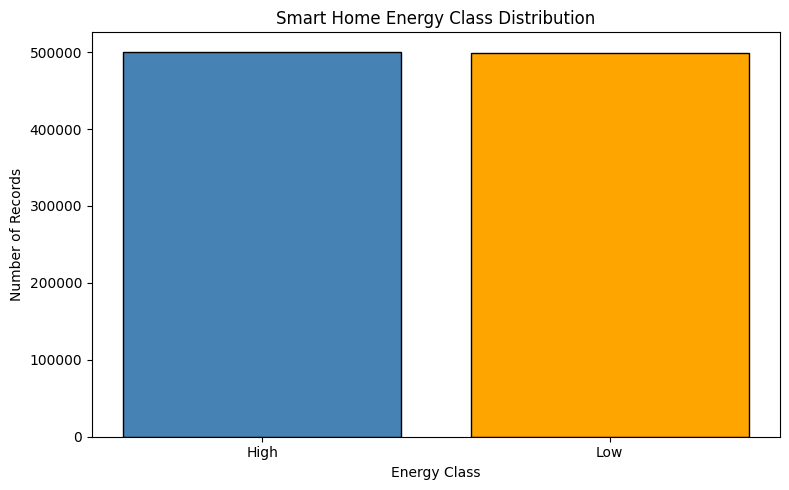

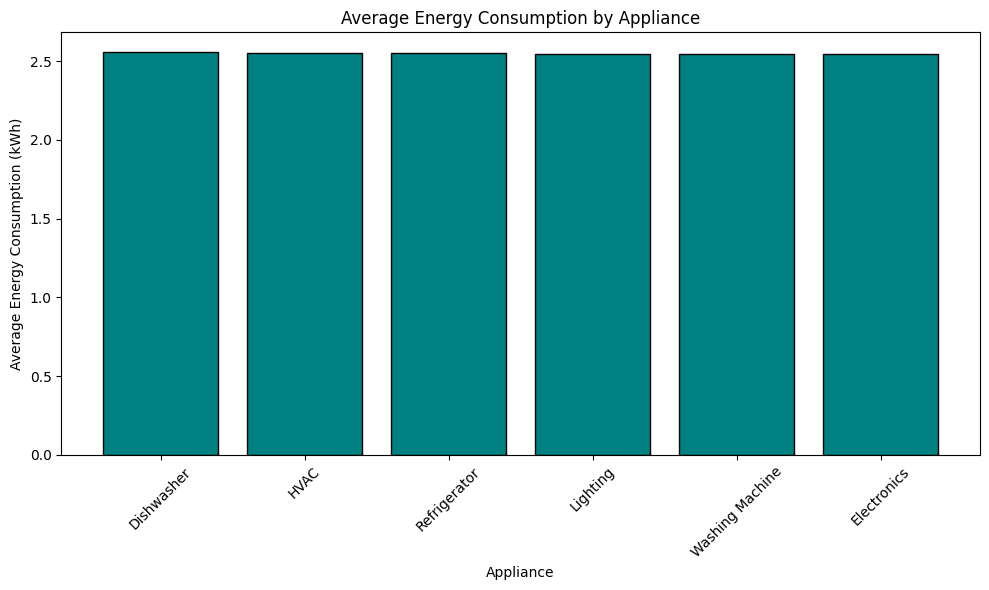

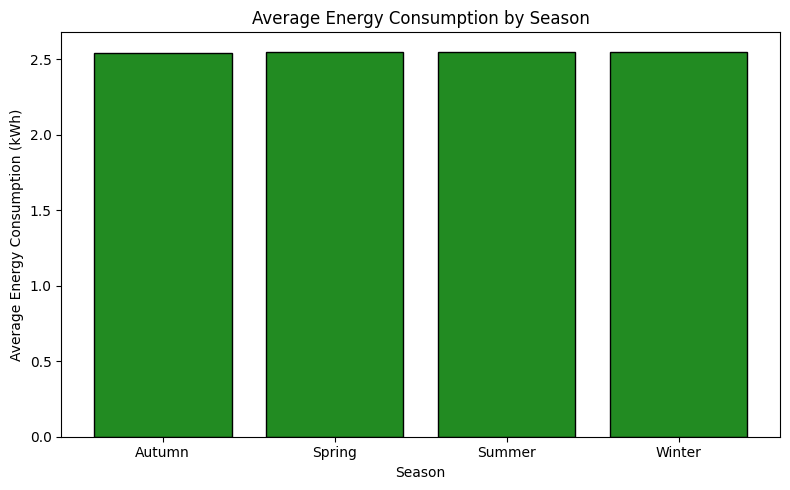

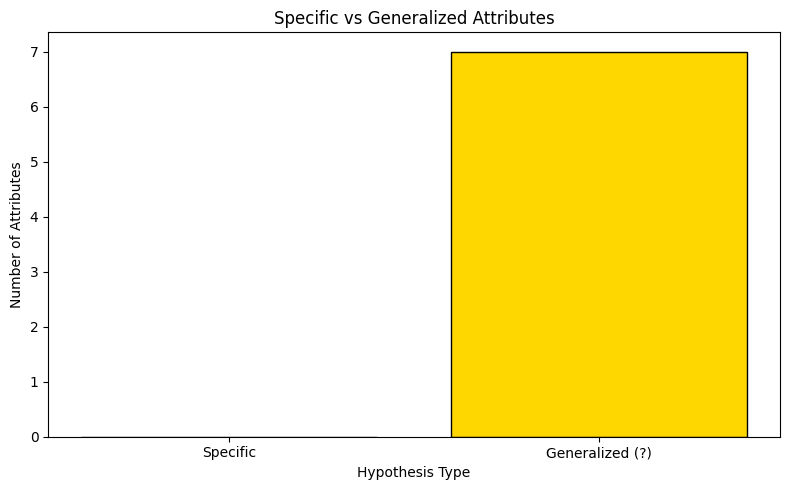

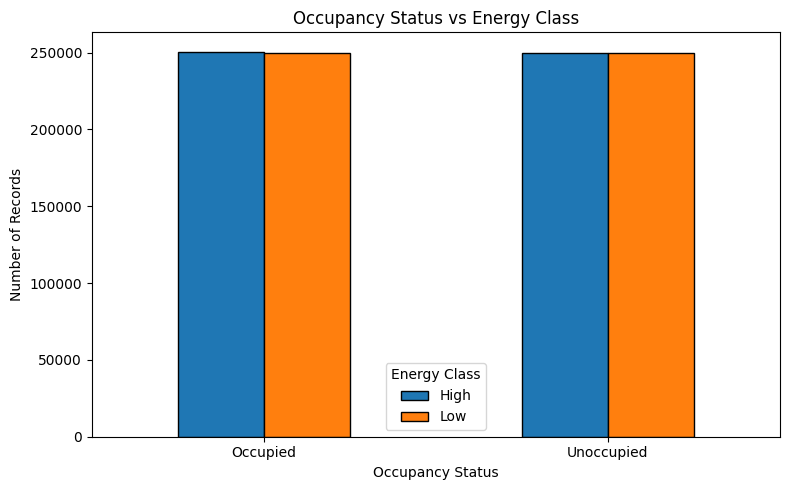

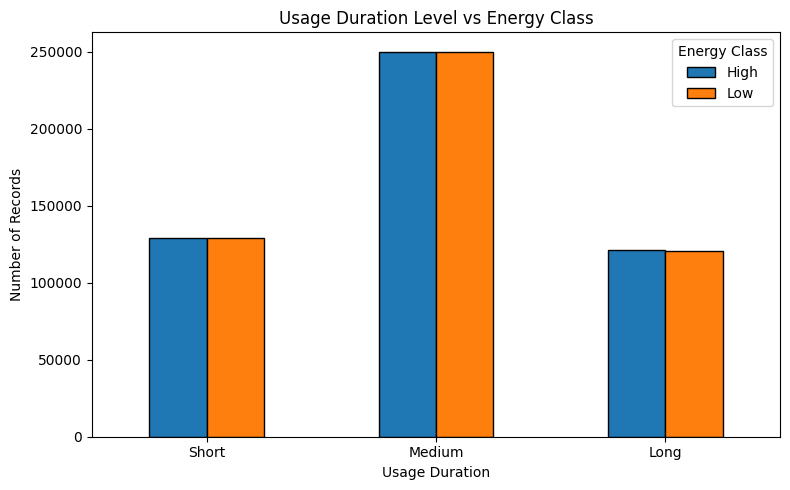


Cleaned dataset saved successfully:
/content/Smart_Home_Energy_Cleaned.csv

Candidate Elimination completed successfully.

Total Records:
1000000

Total Attributes:
7

Positive Examples:
500668

Negative Examples:
499332

Specific Boundary S:
['?', '?', '?', '?', '?', '?', '?']

General Boundary G:
Empty


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file_path = "/content/smart_home_energy_usage_dataset.csv"

df = pd.read_csv(file_path)

print("SMART HOME ENERGY USAGE DATASET")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()

print("\nNumber of Duplicate Records:")
print(duplicate_count)

df = df.drop_duplicates()

print("\nShape After Removing Duplicates:")
print(df.shape)

for column in df.columns:
    if df[column].isnull().any():
        if pd.api.types.is_numeric_dtype(df[column]):
            df[column] = df[column].fillna(df[column].median())
        else:
            df[column] = df[column].fillna(df[column].mode()[0])

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

median_energy = df["energy_consumption_kWh"].median()

df["energy_class"] = df["energy_consumption_kWh"].apply(
    lambda x: "High" if x >= median_energy else "Low"
)

print("\nMedian Energy Consumption:")
print(median_energy)

print("\nEnergy Class Distribution:")
print(df["energy_class"].value_counts())

df["temperature_level"] = pd.cut(
    df["temperature_setting_C"],
    bins=[-np.inf, 18, 22, np.inf],
    labels=["Low", "Medium", "High"]
)

df["usage_level"] = pd.cut(
    df["usage_duration_minutes"],
    bins=[-np.inf, 30, 90, np.inf],
    labels=["Short", "Medium", "Long"]
)

attributes = [
    "occupancy_status",
    "appliance",
    "season",
    "day_of_week",
    "holiday",
    "temperature_level",
    "usage_level"
]

X = df[attributes].astype(str).values
y = df["energy_class"].values

print("\nAttributes:")
print(attributes)

print("\nX Shape:")
print(X.shape)

print("\ny Shape:")
print(y.shape)

print("\nClass Values:")
print(df["energy_class"].unique())

S = ["∅"] * len(attributes)
G = [["?"] * len(attributes)]

def covers(h, x):
    for i in range(len(h)):
        if h[i] != "?" and h[i] != "∅":
            if h[i] != x[i]:
                return False
    return True

for x, label in zip(X, y):

    if label == "High":

        G = [
            g for g in G
            if covers(g, x)
        ]

        if S == ["∅"] * len(attributes):
            S = list(x)

        else:
            for i in range(len(attributes)):
                if S[i] != x[i]:
                    S[i] = "?"

    elif label == "Low":

        new_G = []

        for g in G:

            if covers(g, x):

                for i in range(len(attributes)):

                    if g[i] == "?":

                        if (
                            S[i] != "?"
                            and S[i] != "∅"
                        ):

                            h = g.copy()
                            h[i] = S[i]

                            if h not in new_G:
                                new_G.append(h)

            else:
                new_G.append(g)

        G = new_G

print("\nCANDIDATE ELIMINATION RESULTS")

print("\nNumber of Positive Examples:")
print(sum(y == "High"))

print("\nNumber of Negative Examples:")
print(sum(y == "Low"))

print("\nMost Specific Hypothesis:")
print(S)

print("\nMost General Hypotheses:")

if len(G) == 0:
    print("Empty")
else:
    for g in G:
        print(g)

print("\nFINAL VERSION SPACE")

print("\nSpecific Boundary (S):")
print(S)

print("\nGeneral Boundary (G):")

if len(G) == 0:
    print("Empty")
else:
    for g in G:
        print(g)

print("\nINTERPRETATION OF SPECIFIC HYPOTHESIS")

for attribute, value in zip(attributes, S):
    print(attribute, "=>", value)

class_counts = df["energy_class"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    class_counts.index,
    class_counts.values,
    edgecolor="black",
    color=["steelblue", "orange"]
)

plt.title("Smart Home Energy Class Distribution")
plt.xlabel("Energy Class")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

appliance_energy = (
    df.groupby("appliance")["energy_consumption_kWh"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    appliance_energy.index,
    appliance_energy.values,
    edgecolor="black",
    color="teal"
)

plt.title("Average Energy Consumption by Appliance")
plt.xlabel("Appliance")
plt.ylabel("Average Energy Consumption (kWh)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

season_energy = (
    df.groupby("season")["energy_consumption_kWh"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    season_energy.index,
    season_energy.values,
    edgecolor="black",
    color="forestgreen"
)

plt.title("Average Energy Consumption by Season")
plt.xlabel("Season")
plt.ylabel("Average Energy Consumption (kWh)")

plt.tight_layout()
plt.show()

specific_attributes = sum(
    1 for value in S
    if value != "?"
)

generalized_attributes = sum(
    1 for value in S
    if value == "?"
)

hypothesis_data = {
    "Specific": specific_attributes,
    "Generalized (?)": generalized_attributes
}

plt.figure(figsize=(8, 5))

plt.bar(
    hypothesis_data.keys(),
    hypothesis_data.values(),
    edgecolor="black",
    color=["purple", "gold"]
)

plt.title("Specific vs Generalized Attributes")
plt.xlabel("Hypothesis Type")
plt.ylabel("Number of Attributes")

plt.tight_layout()
plt.show()

occupancy_class = pd.crosstab(
    df["occupancy_status"],
    df["energy_class"]
)

occupancy_class.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

plt.title("Occupancy Status vs Energy Class")
plt.xlabel("Occupancy Status")
plt.ylabel("Number of Records")

plt.xticks(rotation=0)

plt.legend(title="Energy Class")

plt.tight_layout()
plt.show()

usage_class = pd.crosstab(
    df["usage_level"],
    df["energy_class"]
)

usage_class.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

plt.title("Usage Duration Level vs Energy Class")
plt.xlabel("Usage Duration")
plt.ylabel("Number of Records")

plt.xticks(rotation=0)

plt.legend(title="Energy Class")

plt.tight_layout()
plt.show()

output_file = "/content/Smart_Home_Energy_Cleaned.csv"

df.to_csv(
    output_file,
    index=False
)

print("\nCleaned dataset saved successfully:")
print(output_file)

print("\nCandidate Elimination completed successfully.")

print("\nTotal Records:")
print(len(df))

print("\nTotal Attributes:")
print(len(attributes))

print("\nPositive Examples:")
print(sum(y == "High"))

print("\nNegative Examples:")
print(sum(y == "Low"))

print("\nSpecific Boundary S:")
print(S)

print("\nGeneral Boundary G:")

if len(G) == 0:
    print("Empty")
else:
    for g in G:
        print(g)


In [ ]:
import pandas as pd
import numpy as np

file_path = "/content/smart_home_energy_usage_dataset.csv"

df = pd.read_csv(file_path)

print("SMART HOME ENERGY USAGE DATASET")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()

print("\nNumber of Duplicate Records:")
print(duplicate_count)

df = df.drop_duplicates()

print("\nShape After Removing Duplicates:")
print(df.shape)

for column in df.columns:

    if df[column].isnull().any():

        if pd.api.types.is_numeric_dtype(df[column]):

            df[column] = df[column].fillna(
                df[column].median()
            )

        else:

            df[column] = df[column].fillna(
                df[column].mode()[0]
            )

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

median_energy = df["energy_consumption_kWh"].median()

df["energy_class"] = df[
    "energy_consumption_kWh"
].apply(
    lambda x: "High" if x >= median_energy else "Low"
)

print("\nMedian Energy Consumption:")
print(median_energy)

print("\nEnergy Class Distribution:")
print(
    df["energy_class"].value_counts()
)

df["temperature_level"] = pd.cut(
    df["temperature_setting_C"],
    bins=[-np.inf, 18, 22, np.inf],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

df["usage_level"] = pd.cut(
    df["usage_duration_minutes"],
    bins=[-np.inf, 30, 90, np.inf],
    labels=[
        "Short",
        "Medium",
        "Long"
    ]
)

attributes = [
    "occupancy_status",
    "appliance",
    "season",
    "day_of_week",
    "holiday",
    "temperature_level",
    "usage_level"
]

X = df[attributes].astype(str).values

y = df["energy_class"].values

print("\nAttributes:")
print(attributes)

print("\nX Shape:")
print(X.shape)

print("\ny Shape:")
print(y.shape)

print("\nClass Values:")
print(df["energy_class"].unique())

S = ["∅"] * len(attributes)

G = [["?"] * len(attributes)]


def covers(h, x):

    for i in range(len(h)):

        if h[i] != "?" and h[i] != "∅":

            if h[i] != x[i]:

                return False

    return True


for x, label in zip(X, y):

    if label == "High":

        G = [
            g for g in G
            if covers(g, x)
        ]

        if S == ["∅"] * len(attributes):

            S = list(x)

        else:

            for i in range(len(attributes)):

                if S[i] != x[i]:

                    S[i] = "?"

    elif label == "Low":

        new_G = []

        for g in G:

            if covers(g, x):

                for i in range(len(attributes)):

                    if g[i] == "?":

                        if (
                            S[i] != "?"
                            and S[i] != "∅"
                        ):

                            h = g.copy()

                            h[i] = S[i]

                            if h not in new_G:

                                new_G.append(h)

            else:

                new_G.append(g)

        G = new_G


print("\nCANDIDATE ELIMINATION RESULTS")

print("\nNumber of Positive Examples:")
print(sum(y == "High"))

print("\nNumber of Negative Examples:")
print(sum(y == "Low"))

print("\nMost Specific Hypothesis:")
print(S)

print("\nMost General Hypotheses:")

if len(G) == 0:

    print("Empty")

else:

    for g in G:

        print(g)


print("\nFINAL VERSION SPACE")

print("\nSpecific Boundary (S):")
print(S)

print("\nGeneral Boundary (G):")

if len(G) == 0:

    print("Empty")

else:

    for g in G:

        print(g)


print("\nINTERPRETATION OF SPECIFIC HYPOTHESIS")

for attribute, value in zip(attributes, S):

    print(
        attribute,
        "=>",
        value
    )


output_file = "/content/Smart_Home_Energy_Cleaned.csv"

df.to_csv(
    output_file,
    index=False
)

print("\nCleaned dataset saved successfully:")

print(output_file)

print("\nCandidate Elimination completed successfully.")

print("\nTotal Records:")
print(len(df))

print("\nTotal Attributes:")
print(len(attributes))

print("\nPositive Examples:")
print(sum(y == "High"))

print("\nNegative Examples:")
print(sum(y == "Low"))

print("\nSpecific Boundary S:")
print(S)

print("\nGeneral Boundary G:")

if len(G) == 0:

    print("Empty")

else:

    for g in G:

        print(g)


SMART HOME ENERGY USAGE DATASET
             timestamp  home_id  energy_consumption_kWh  \
0  2023-01-01 00:00:00       44                    2.87   
1  2023-01-01 01:00:00       81                    0.56   
2  2023-01-01 02:00:00       94                    4.49   
3  2023-01-01 03:00:00       20                    2.13   
4  2023-01-01 04:00:00        3                    2.74   

   temperature_setting_C occupancy_status     appliance  \
0                   22.1         Occupied  Refrigerator   
1                   15.4         Occupied          HVAC   
2                   22.4         Occupied   Electronics   
3                   24.6       Unoccupied    Dishwasher   
4                   21.4       Unoccupied          HVAC   

   usage_duration_minutes  season day_of_week  holiday  
0                     111  Spring      Sunday        0  
1                     103  Summer      Sunday        0  
2                      12  Autumn      Sunday        0  
3                      54  Aut